# 04 — Inférence nationale, priorisation et incertitude

**Objectif :** Reproduire et visualiser le pipeline post-modélisation à résolution ~1 km :

1. Couverture raster GEE v3 (VIIRS NASA/002)
2. Inférence wealth raster directe (LightGBM z-score)
3. Carte de priorisation Phase 2 (pauvreté + accessibilité OSM)
4. Carte d'incertitude OOF alignée sur la grille modèle

> Ce notebook **ne nécessite pas GEE** si les artefacts sont déjà générés localement.
> Pour régénérer les rasters : voir section « Régénération » en fin de notebook.

In [1]:
from pathlib import Path
import json
import sys

import pandas as pd
from IPython.display import Image, display, Markdown

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

REPORTS = PROJECT_ROOT / "outputs/reports"
MAPS = PROJECT_ROOT / "outputs/maps"
RASTERS = PROJECT_ROOT / "data/processed/rasters"

ARTIFACTS = {
    "features_mosaic": RASTERS / "cm_features_1km_v3.tif",
    "wealth_model": MAPS / "wealth_index_predicted_1km_model.tif",
    "wealth_z": MAPS / "wealth_index_predicted_1km_model_z.tif",
    "priority": MAPS / "priority_index_1km.tif",
    "uncertainty": MAPS / "wealth_uncertainty_1km_model.tif",
    "viirs_report": REPORTS / "viirs_reexport_final.json",
    "prioritization": REPORTS / "prioritization_results.json",
    "uncertainty_report": REPORTS / "national_uncertainty.json",
    "model_results": REPORTS / "real_model_results.json",
}

for name, path in ARTIFACTS.items():
    status = "✅" if path.exists() else "❌"
    size = f" ({path.stat().st_size / 1e6:.1f} MB)" if path.exists() and path.is_file() else ""
    print(f"{status} {name}: {path.name}{size}")


✅ features_mosaic: cm_features_1km_v3.tif (13.5 MB)
✅ wealth_model: wealth_index_predicted_1km_model.tif (1.1 MB)
✅ wealth_z: wealth_index_predicted_1km_model_z.tif (1.1 MB)
✅ priority: priority_index_1km.tif (1.6 MB)
✅ uncertainty: wealth_uncertainty_1km_model.tif (4.4 MB)
✅ viirs_report: viirs_reexport_final.json (0.0 MB)
✅ prioritization: prioritization_results.json (0.0 MB)
✅ uncertainty_report: national_uncertainty.json (0.0 MB)
✅ model_results: real_model_results.json (0.0 MB)


## 1. Couverture nationale (tuiles GEE)

In [2]:
import subprocess

subprocess.run(
    [sys.executable, str(PROJECT_ROOT / "scripts/check_raster_progress.py")],
    cwd=PROJECT_ROOT,
    check=False,
)


CompletedProcess(args=['C:\\~\\Projects\\cameroon-poverty-mapping\\.venv\\Scripts\\python.exe', 'C:\\~\\Projects\\cameroon-poverty-mapping\\scripts\\check_raster_progress.py'], returncode=0)

## 2. Métriques modèle (VIIRS NASA/002)

In [3]:
if ARTIFACTS["model_results"].exists():
    report = json.loads(ARTIFACTS["model_results"].read_text(encoding="utf-8"))
    m = report["metrics_oof"]
    print(f"R² OOF      : {m['r2']:.4f}")
    print(f"Spearman    : {m['spearman']:.4f}")
    print(f"RMSE        : {m['rmse']:.2f}")
    print(f"Feature set : {report.get('feature_set')}")
else:
    print("❌ real_model_results.json manquant — lancez run_real_model_evaluation.py")


R² OOF      : 0.7867
Spearman    : 0.8818
RMSE        : 38940.86
Feature set : v3


## 3. Rapport ré-export VIIRS

In [4]:
if ARTIFACTS["viirs_report"].exists():
    viirs = json.loads(ARTIFACTS["viirs_report"].read_text(encoding="utf-8"))
    display(pd.Series(viirs))
else:
    print("ℹ️  viirs_reexport_final.json absent — pipeline VIIRS pas encore finalisé")


timestamp_utc                        2026-07-10T06:55:41.332246+00:00
viirs_collection                               NASA/VIIRS/002/VNP46A2
complete                                                         True
mosaic              C:\~\Projects\cameroon-poverty-mapping\data\pr...
wealth_map          C:\~\Projects\cameroon-poverty-mapping\outputs...
priority_map        C:\~\Projects\cameroon-poverty-mapping\outputs...
dtype: object

## 4. Carte wealth raster (inférence GEE directe)

### Wealth index — raster modèle 1 km

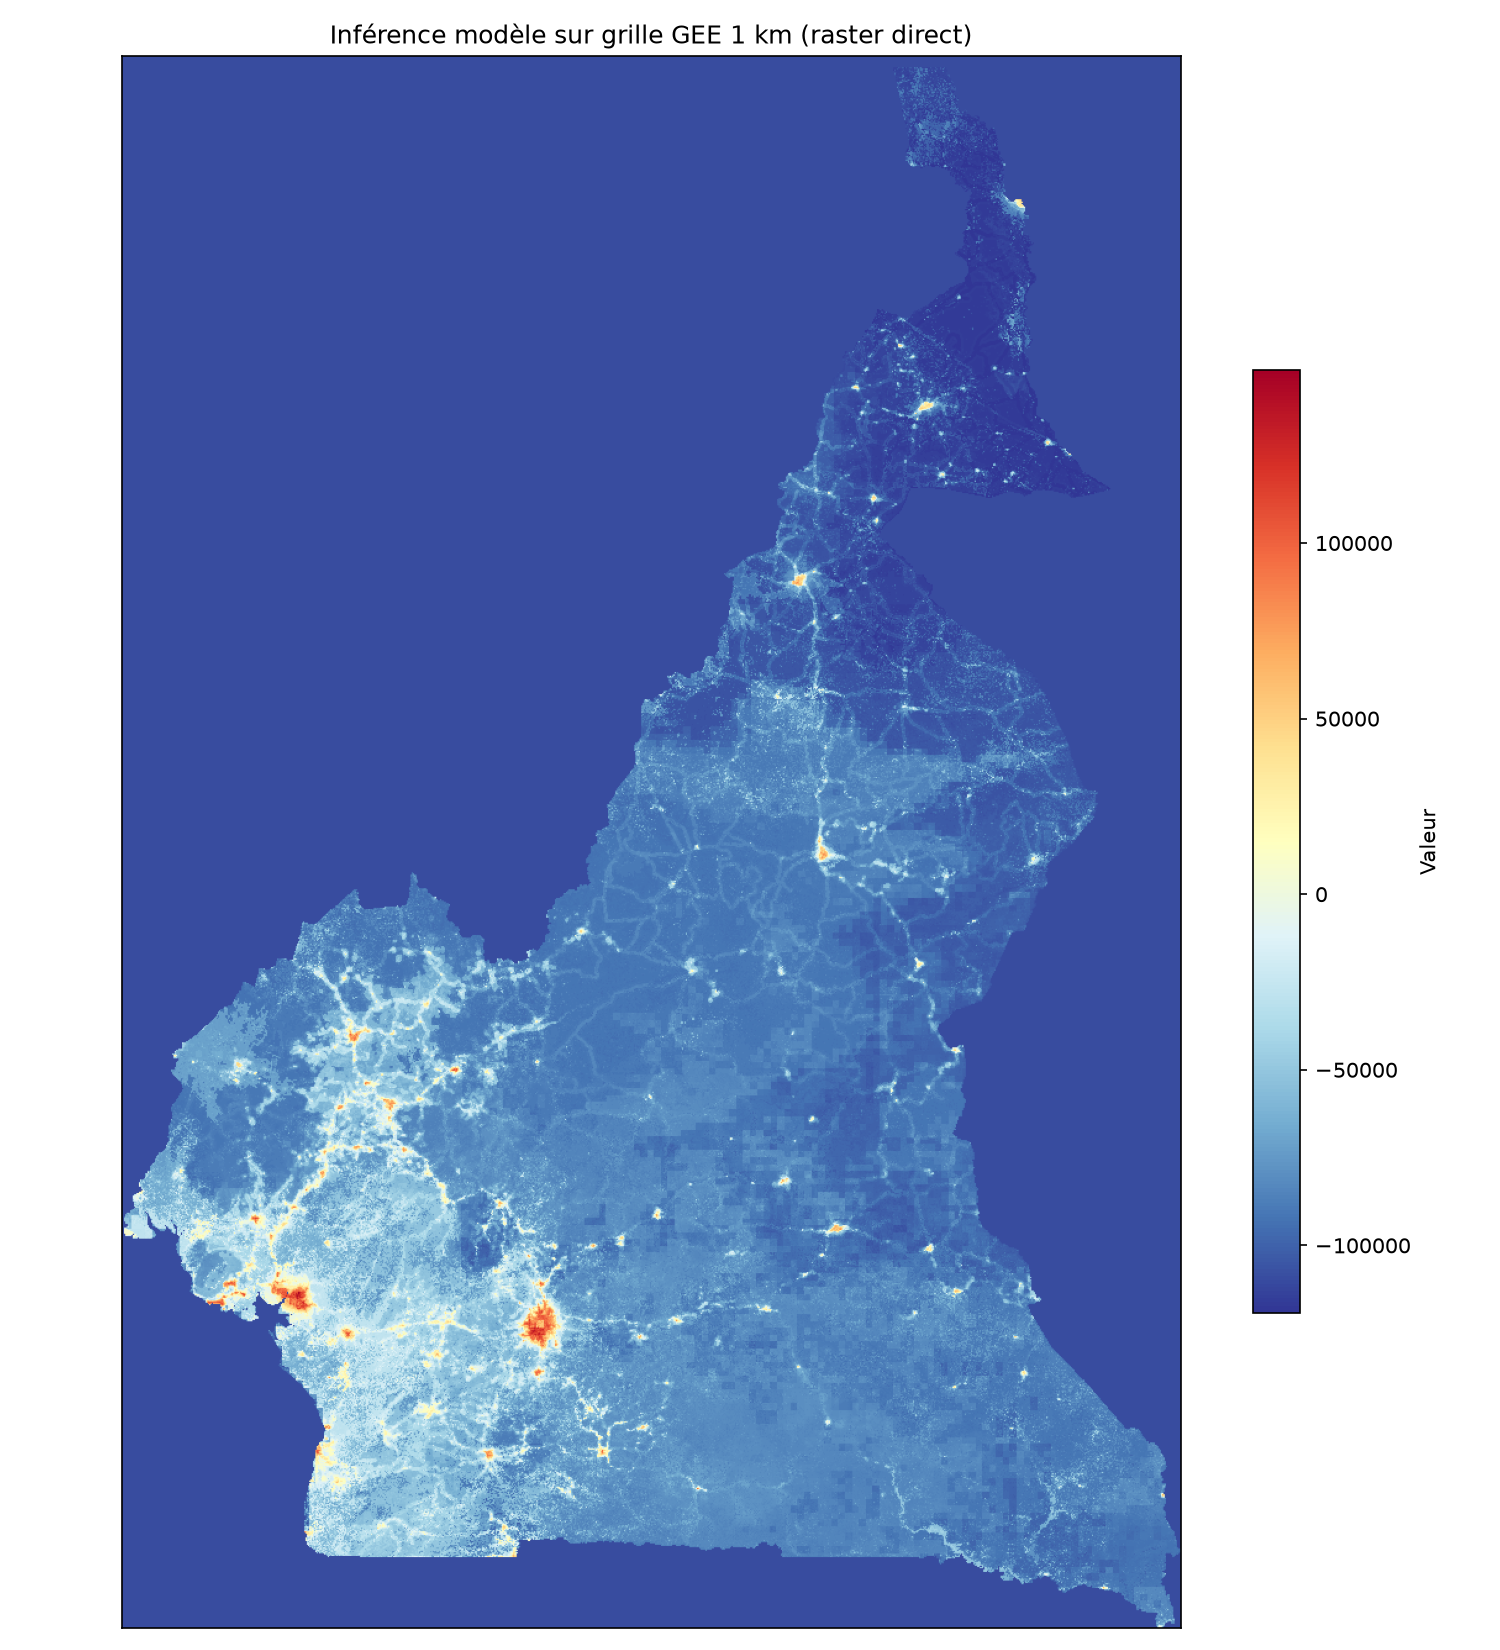

In [5]:
wealth_png = MAPS / "wealth_index_predicted_1km_model.png"
if wealth_png.exists():
    display(Markdown("### Wealth index — raster modèle 1 km"))
    display(Image(filename=str(wealth_png)))
else:
    print("❌ Lancez : python scripts/run_national_inference.py --mode raster --features data/processed/rasters/cm_features_1km_v3.tif")


## 5. Carte de priorisation (Phase 2)

### Top 10 grappes prioritaires

,cluster_id,region,priority_index,predicted_wealth,dist_school_km,dist_health_km,dist_road_km
0,266,Nord-Ouest,0.9933,-101790.76,37.63,50.00,13.35
1,105,Nord,0.9800,-101370.53,49.90,49.93,2.74
2,59,Nord,0.9672,-116542.47,50.00,50.00,2.09
3,215,Extrême-Nord,0.9620,-105727.57,32.83,40.56,3.46
4,269,Adamaoua,0.9605,-91247.06,29.03,50.00,22.11
5,276,Adamaoua,0.9374,-79705.60,39.82,49.46,8.58
6,171,Adamaoua,0.9361,-88641.91,30.38,50.00,2.33
7,27,Est,0.9352,-84286.18,35.87,50.00,2.63
8,85,Adamaoua,0.9307,-89658.86,39.91,50.00,2.09
9,344,Adamaoua,0.9301,-89242.29,36.41,47.13,2.46


### Carte priorisation composite

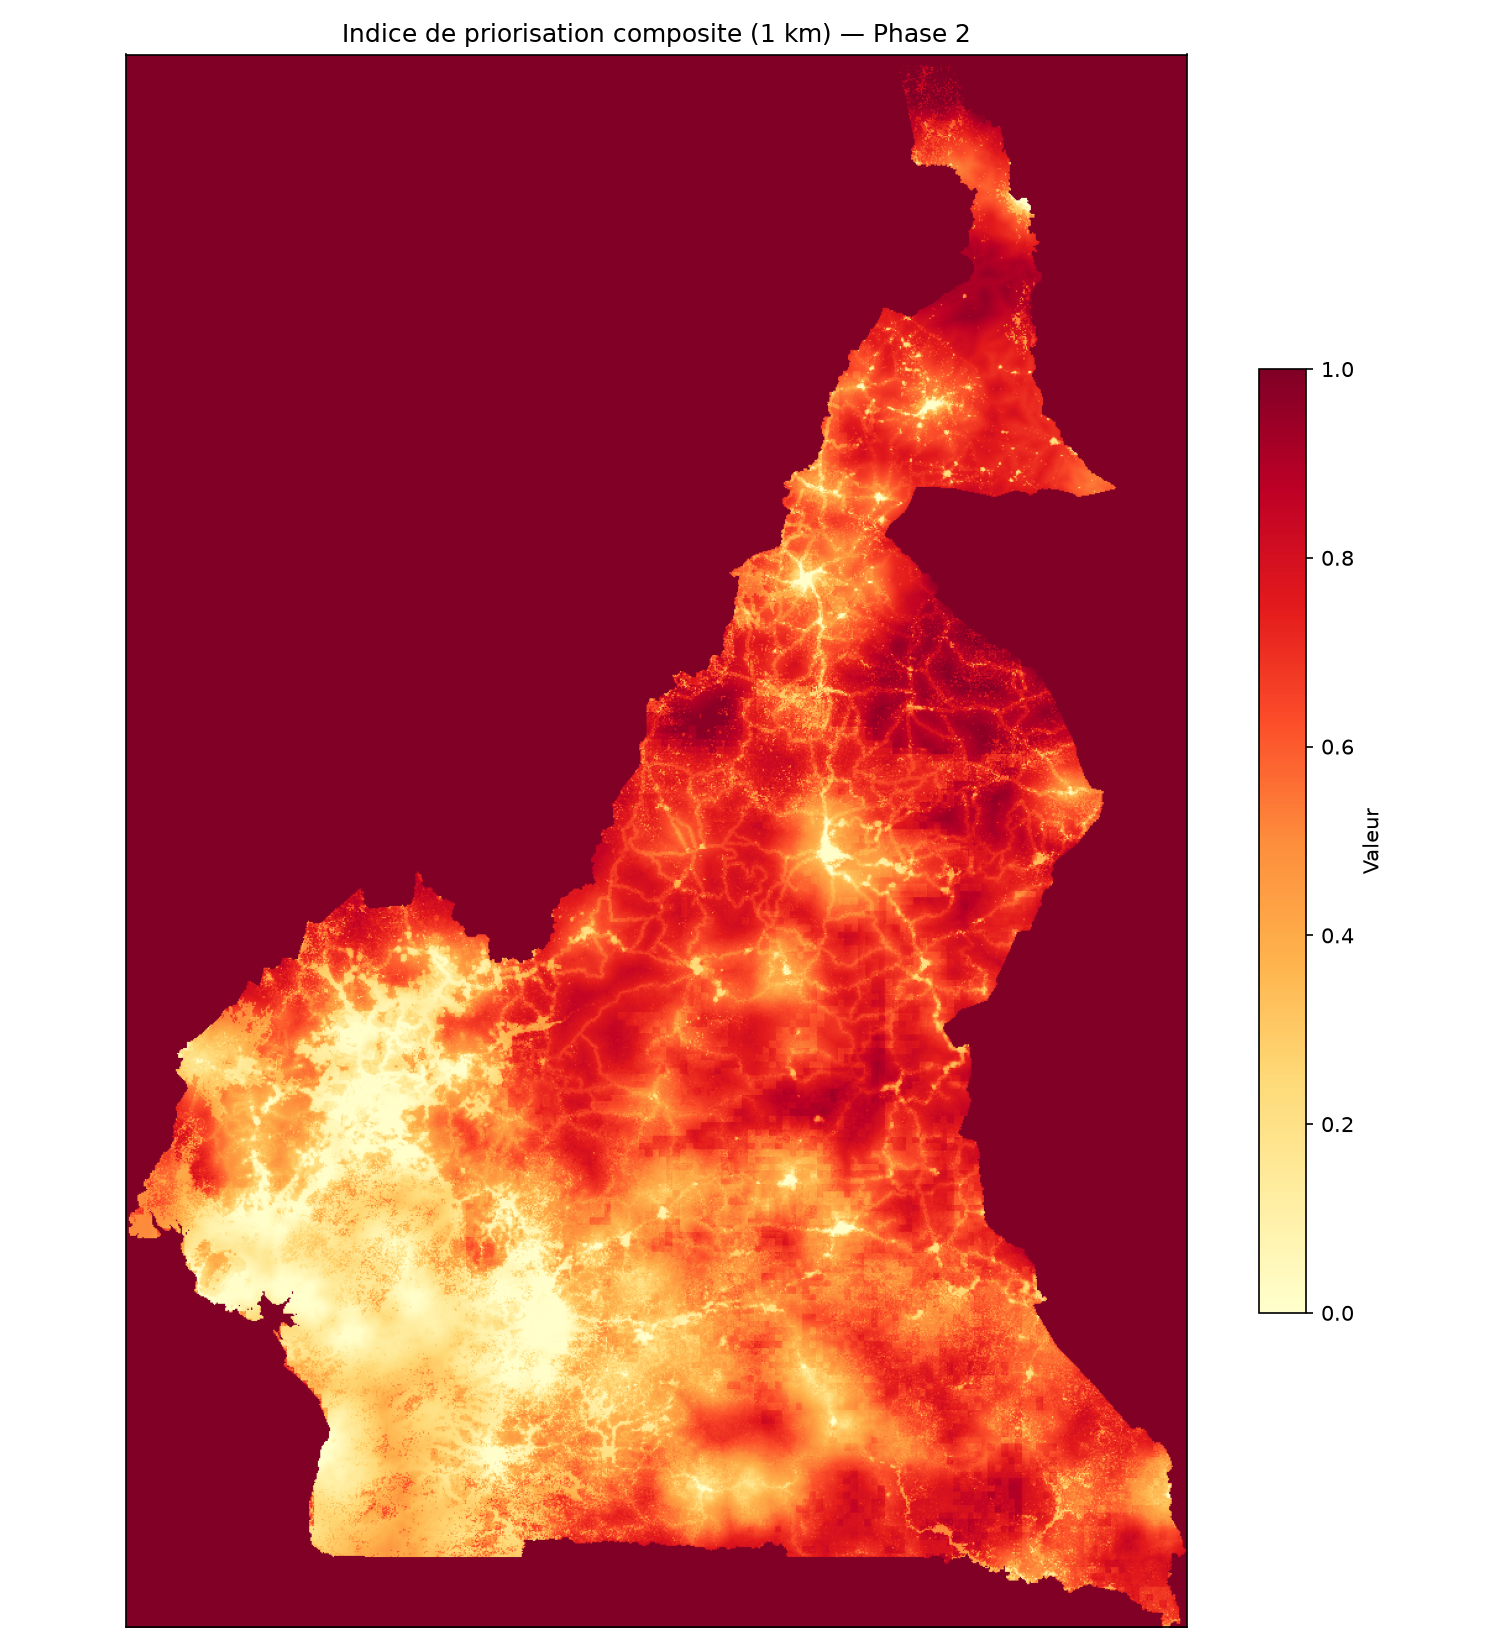

In [6]:
prio_png = MAPS / "priority_index_1km.png"
if ARTIFACTS["prioritization"].exists():
    prio = json.loads(ARTIFACTS["prioritization"].read_text(encoding="utf-8"))
    top = pd.DataFrame(prio["top_clusters"]).head(10)
    display(Markdown("### Top 10 grappes prioritaires"))
    display(top)
if prio_png.exists():
    display(Markdown("### Carte priorisation composite"))
    display(Image(filename=str(prio_png)))
else:
    print("❌ Lancez : python scripts/run_prioritization_maps.py")


## 6. Carte d'incertitude (grille modèle)

### Incertitude OOF — demi-largeur 90 %

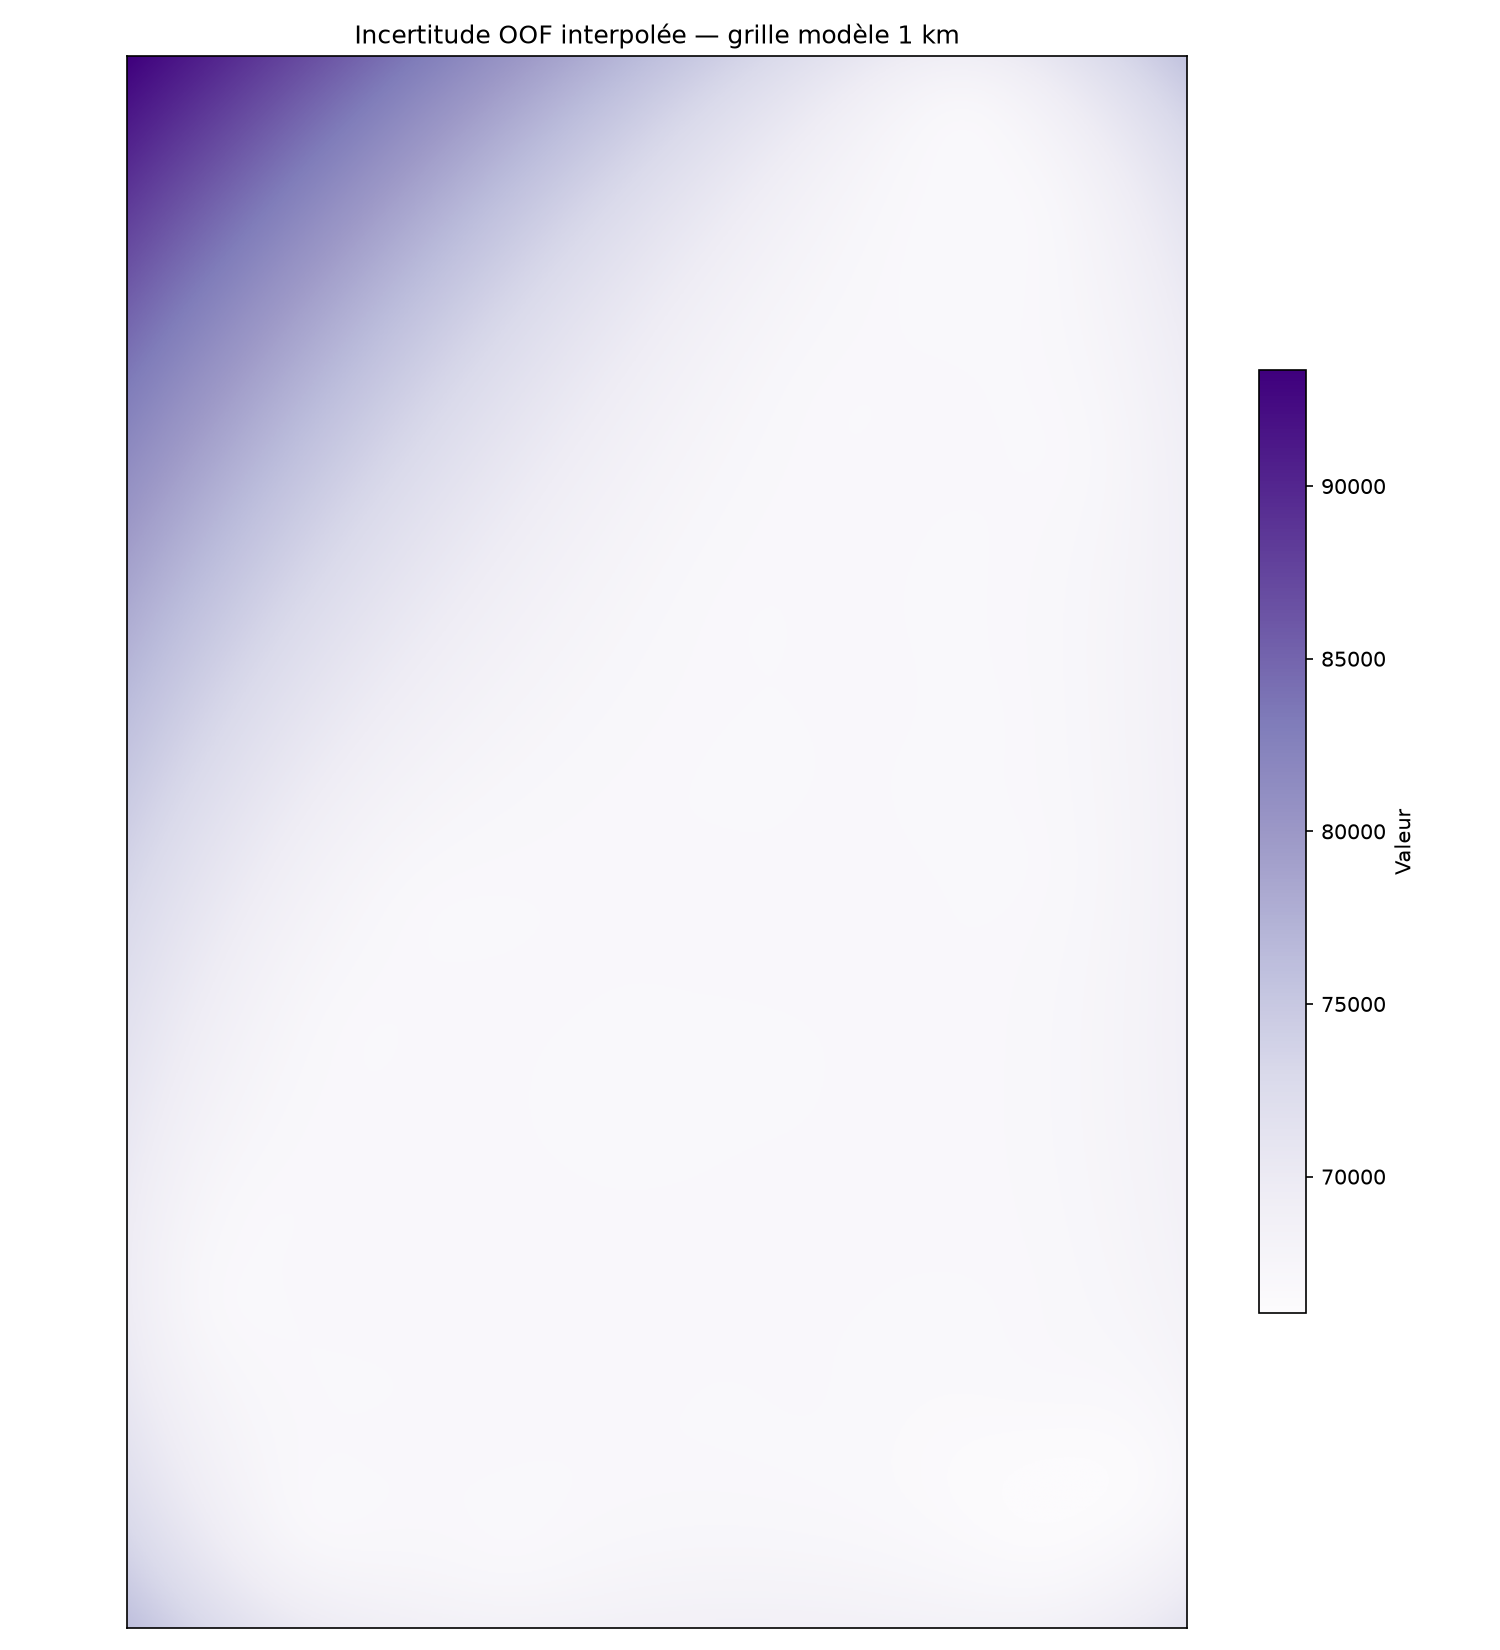

In [7]:
unc_png = MAPS / "wealth_uncertainty_1km_model.png"
if unc_png.exists():
    display(Markdown("### Incertitude OOF — demi-largeur 90 %"))
    display(Image(filename=str(unc_png)))
else:
    print("❌ Lancez : python scripts/run_national_uncertainty.py")


## 7. Régénération complète (optionnel)

Commandes pour reconstruire tous les artefacts nationaux :

```bash
# Après export GEE + téléchargement 96 tuiles
python scripts/finalize_viirs_reexport.py

# Ou étape par étape :
python scripts/run_national_inference.py --mode raster --features data/processed/rasters/cm_features_1km_v3.tif
python scripts/run_prioritization_maps.py
python scripts/run_national_uncertainty.py
```

## Limites

- Les cartes raster sont **exploratoires** (pas de validation terrain).
- L'incertitude est une **approximation OOF globale** interpolée depuis 430 grappes.
- La priorisation combine des pondérations configurables (`configs/prioritization_criteria.yaml`).